# Supplementary Figure S8: `s08_fair_filtering`

**Structure of synthesis failures.** A synthesized image "fails" when its own post-hoc prediction misses the intended target by more than a fraction $\tau$ of the channel's target range ($\mathrm{relerr} = |\mathrm{target} - \mathrm{achieved}| / \mathrm{range} > \tau$); the target grid is shared across models within a channel, so this criterion is comparable across models. (A) Success rate ($100 \times$ the fraction of stimuli with $\mathrm{relerr} \le \tau$), shown as model ($y$, $10$ models colored by family with adversarially trained models in bold) by feature level ($x$, $11$ target levels $0$--$10$) heatmaps (RdYlGn, $0$--$100%$) at the strict ($\tau = 2%$ of range) and lenient ($\tau = 5%$) tolerances, pooled over all sites and seeds across the $5$ macaques. Failures tend to be non-uniform, instead concentrating at the strongest drive levels and disproportionately arising from specific models (e.g. RN50-CLIP). Relaxing the success criterion threshold to $\tau = 5%$ mitigates many error cases. (B) Distribution of miss magnitude $|\mathrm{target} - \mathrm{achieved}|$ (% of range) among failure cases only ($\mathrm{relerr} > 2%$, so the success spike near $0$ is excluded to expose the tail); dashed orange line marks the $5%$ tolerance. Most misses are small, with a long right tail.

Rendered by `figures/supplementary/sup_fair_filtering.py`; the PNG written below is pixel-identical to the manuscript file `s08_fair_filtering.png` in the reference environment (see docs/REPRODUCIBILITY.md). The preview shown here is downscaled.

In [1]:
import os, sys
from pathlib import Path

# Keep BLAS single-threaded: multithreaded OpenMP together with torch can kill the kernel on macOS.
for _v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ.setdefault(_v, '1')
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

# Render with the Agg backend and matplotlib's defaults, exactly like the figure scripts;
# Jupyter's inline backend would otherwise change dpi and bounding boxes.
os.environ['MPLBACKEND'] = 'Agg'
import matplotlib; matplotlib.use('Agg'); matplotlib.rcdefaults()

# Work from the repository root whether the notebook is opened there or in notebooks/figures/.
REPO = Path.cwd() if (Path.cwd() / 'pnc').exists() else Path.cwd().parents[1]
sys.path.insert(0, str(REPO))
from pnc import paths

# The figures read the preprocessed caches only; this raises a clear message if they are missing.
paths.require(paths.preprocessed_data() / 'brain_red.pkl')   # python data/download_data.py --tier preprocessed
out_dir = paths.output_dir() / 'figures'
out_dir.mkdir(parents=True, exist_ok=True)

In [2]:
from figures.supplementary.sup_fair_filtering import main

# main() writes <out_dir>/<manuscript name>.png (border-trimmed, so it matches the submitted file)
# and returns its path; keyword arguments select the non-default variants documented in the script.
png = main(str(out_dir))
print(png)

Saved -> /private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/s08_fair_filtering.png
/private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/s08_fair_filtering.png


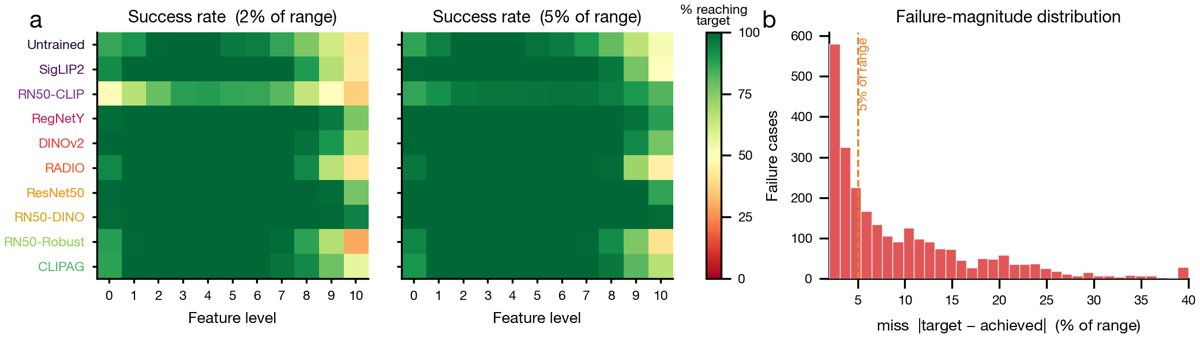

In [3]:
import io
from IPython.display import Image, display
from PIL import Image as PILImage

# Show a downscaled JPEG preview (the full-resolution PNG can be tens of MB); open the file for detail.
im = PILImage.open(png).convert("RGB")
im.thumbnail((1200, 1200))
buf = io.BytesIO(); im.save(buf, "JPEG", quality=85, optimize=True)
display(Image(data=buf.getvalue(), format="jpeg", width=900))